In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("Hotel Reservations.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
df.drop(columns='Booking_ID',inplace=True)
df=pd.get_dummies(data=df,drop_first=True)

In [4]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'booking_status_Not_Canceled'],
      dtype='object')

In [5]:
x=df[['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online']]
y=df["booking_status_Not_Canceled"]

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

In [12]:
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,recall_score
accurecy=[]
model
for i in range(1,21):
    model = DecisionTreeClassifier(criterion='entropy',max_depth=i,random_state=42)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    accurecy.append(accuracy_score(y_test,y_pred))

In [13]:
print(accurecy)

[0.7651274982770503, 0.7651274982770503, 0.7830461750516885, 0.8137835975189525, 0.830737422467264, 0.833907649896623, 0.850999310820124, 0.8578911095796002, 0.867539627842867, 0.868090971743625, 0.8745692625775328, 0.8796691936595451, 0.8781529979324604, 0.882012405237767, 0.8784286698828394, 0.878566505858029, 0.8773259820813232, 0.8773259820813232, 0.8766368022053757, 0.8760854583046175]


In [16]:
print((accurecy.index(max(accurecy)))+1)

14


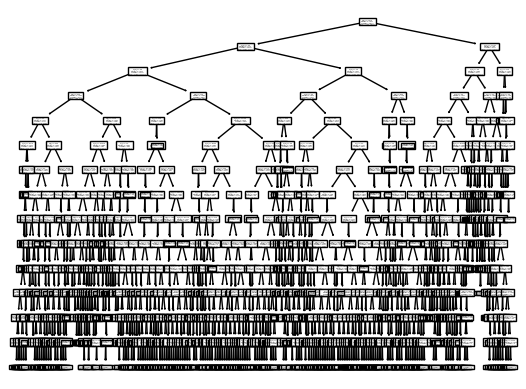

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier ,plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,recall_score

model = DecisionTreeClassifier(criterion='entropy',max_depth=14,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
plot_tree(model)
plt.show()